In [1]:
! pip install pandas matplotlib numpy -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Aluno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('vendas_cursos_desbalanceado_5000.csv')

In [ ]:
#anality inicial dos dados

df.head()

,id_venda,curso,valor,idade,cidade,forma_pagamento,avaliacao,status,data_venda
0,1,Python,216.96,55,Vitória da Conquista,Cartão,3,Concluído,2025-03-21
1,2,Python,135.85,38,Lauro de Freitas,Cartão,5,Em andamento,2025-06-04
2,3,Java,541.40,54,Lauro de Freitas,PIX,1,Em andamento,2025-06-12
3,4,Python,572.76,29,Lauro de Freitas,Cartão,5,Concluído,2025-10-06
4,5,SQL,583.23,23,Vitória da Conquista,Cartão,2,Em andamento,2025-06-19


In [5]:
df.tail()

,id_venda,curso,valor,idade,cidade,forma_pagamento,avaliacao,status,data_venda
4995,4996,Python,339.32,24,Salvador,Boleto,1,Concluído,2025-03-16
4996,4997,Python,872.20,65,Lauro de Freitas,PIX,3,Concluído,2025-06-28
4997,4998,Python,350.46,55,Feira de Santana,Cartão,1,Concluído,2025-09-26
4998,4999,Python,819.63,50,Lauro de Freitas,Boleto,5,Concluído,2025-11-15
4999,5000,Python,677.25,31,Feira de Santana,Boleto,5,Concluído,2025-08-18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venda         5000 non-null   int64  
 1   curso            5000 non-null   object 
 2   valor            5000 non-null   float64
 3   idade            5000 non-null   int64  
 4   cidade           5000 non-null   object 
 5   forma_pagamento  5000 non-null   object 
 6   avaliacao        5000 non-null   int64  
 7   status           5000 non-null   object 
 8   data_venda       5000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 351.7+ KB


In [7]:
df.describe()

,id_venda,valor,idade,avaliacao
count,5000.000000,5000.000000,5000.00000,5000.000000
mean,2500.500000,554.425140,41.80220,2.995600
std,1443.520003,259.924529,14.01609,1.412083
min,1.000000,99.950000,18.00000,1.000000
25%,1250.750000,333.600000,30.00000,2.000000
50%,2500.500000,553.885000,42.00000,3.000000
75%,3750.250000,784.655000,54.00000,4.000000
max,5000.000000,999.740000,65.00000,5.000000


In [8]:
# Quantos cursos vendidos

cursos = df['curso'].value_counts()

In [9]:
cursos

curso
Python      2500
Excel       1200
Power BI     700
SQL          400
Java         150
C#            50
Name: count, dtype: int64

In [18]:
pagamentos = df['forma_pagamento'].value_counts()

pagamentos

forma_pagamento
PIX       1713
Cartão    1650
Boleto    1637
Name: count, dtype: int64

In [19]:
status_pagamentos = df['status'].value_counts()

status_pagamentos

status
Concluído       3277
Em andamento    1224
Cancelado        499
Name: count, dtype: int64

# Grafico de barras

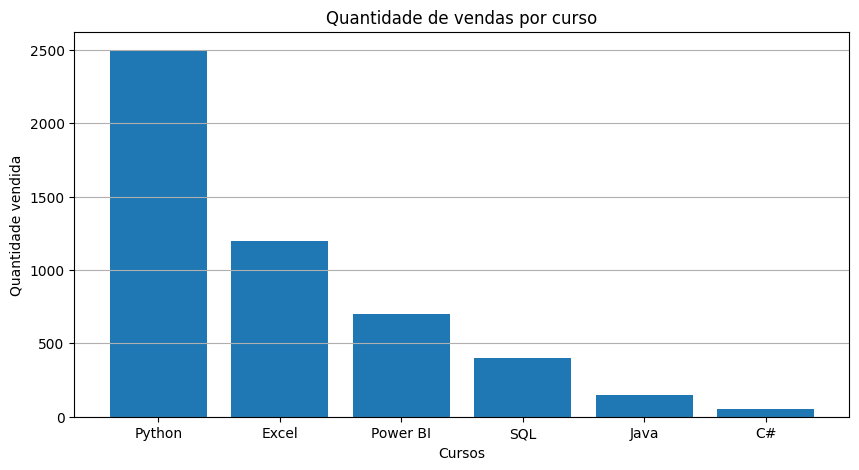

In [29]:

# criar a area do grafico
plt.figure(figsize=(10,5))

# Variaveis ou dados presentes no grafico
plt.bar(cursos.index, cursos.values)

# Definir titulo do grafico
plt.title('Quantidade de vendas por curso')

# Definir legenda inferior (eixo X)
plt.xlabel('Cursos')

# Definir legenda lateral (eixo Y)
plt.ylabel('Quantidade vendida')

plt.grid(axis='y')
plt.show()

# Grafico de pizza

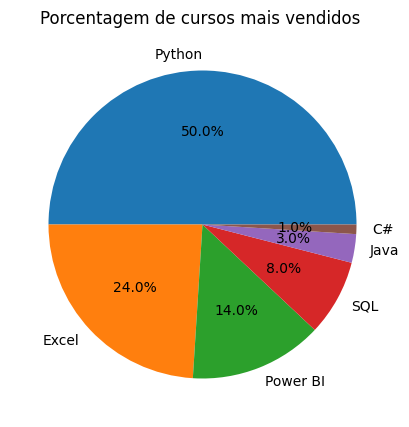

In [33]:
plt.figure(figsize=(5,5))
plt.pie(cursos.values, labels=cursos.index, autopct='%1.1f%%')
plt.title('Porcentagem de cursos mais vendidos ')
plt.show()


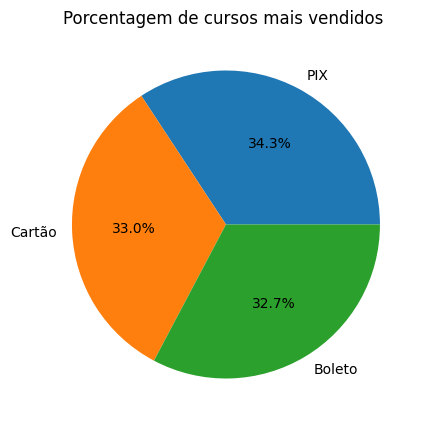

In [37]:
plt.figure(figsize=(5,5))
plt.pie(pagamentos.values, labels=pagamentos.index, autopct='%1.1f%%')
plt.title('Porcentagem de cursos mais vendidos ')
plt.show()


# Grafico histograma

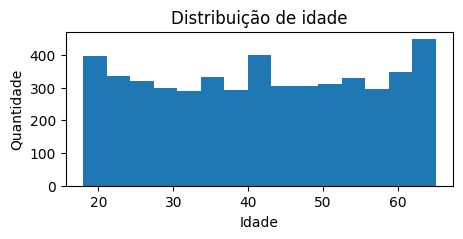

In [40]:
plt.figure(figsize=(5,2))
plt.hist(df['idade'], bins=15)
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.title('Distribuição de idade')
plt.show()

# Grafico de linhas

In [47]:
# Construção dos dados que vou usar

df['data_venda'] = pd.to_datetime(df['data_venda'])

vendas_mes = df.groupby(df['data_venda'].dt.month)['id_venda'].count()

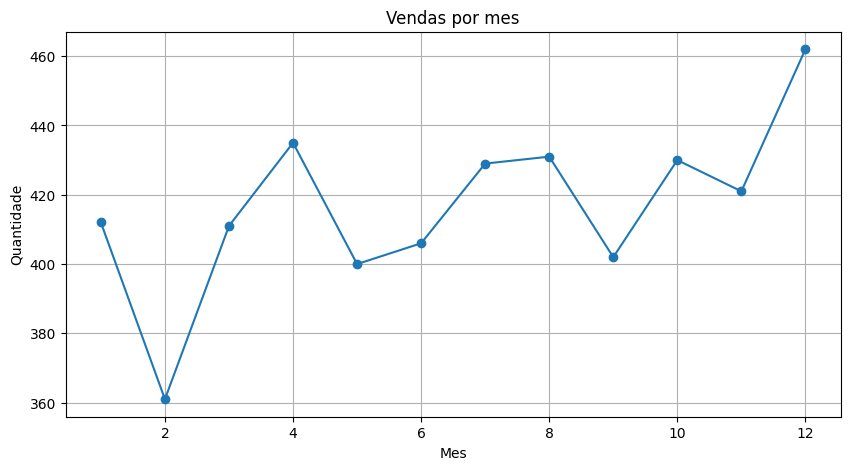

In [56]:
plt.figure(figsize=(10,5))
plt.plot(vendas_mes.index, vendas_mes.values, marker= 'o')
plt.title('Vendas por mes')
plt.xlabel('Mes')
plt.ylabel('Quantidade')
plt.grid()
plt.show()

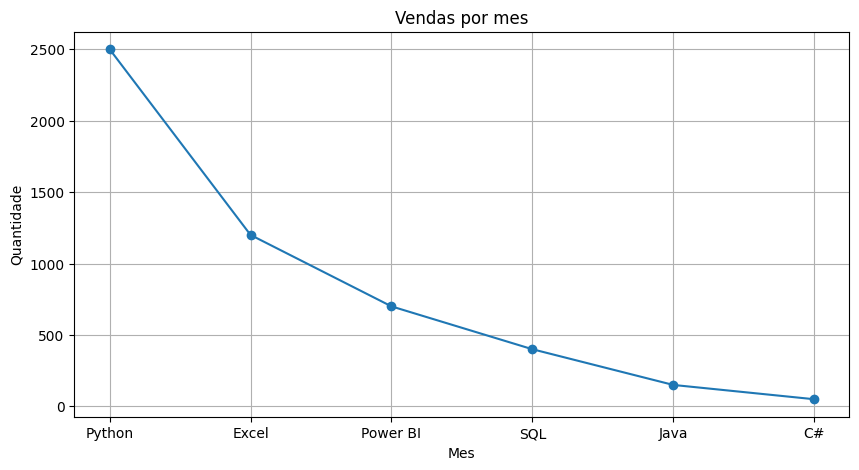

In [57]:
plt.figure(figsize=(10,5))
plt.plot(cursos.index, cursos.values, marker= 'o')
plt.title('Vendas por mes')
plt.xlabel('Mes')
plt.ylabel('Quantidade')
plt.grid()
plt.show()

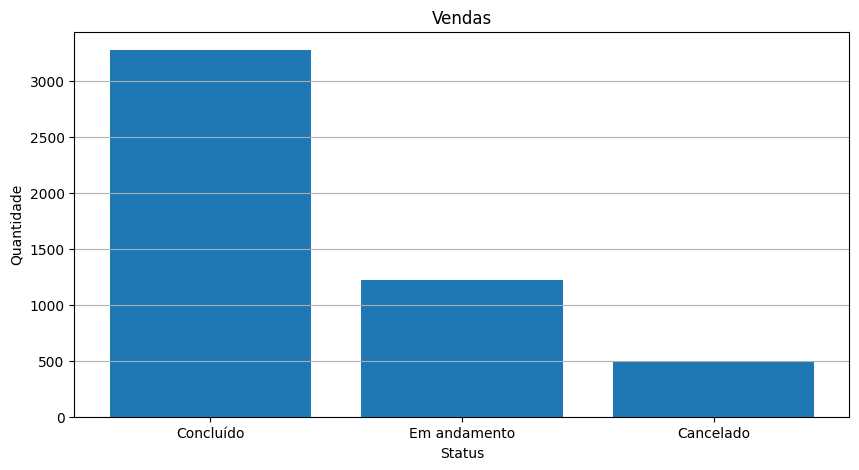

In [67]:
#1.

plt.figure(figsize=(10,5))
plt.bar(status_pagamentos.index, status_pagamentos.values)
plt.title('Vendas')
plt.xlabel('Status')
plt.ylabel('Quantidade')
plt.grid(axis='y')
plt.show()

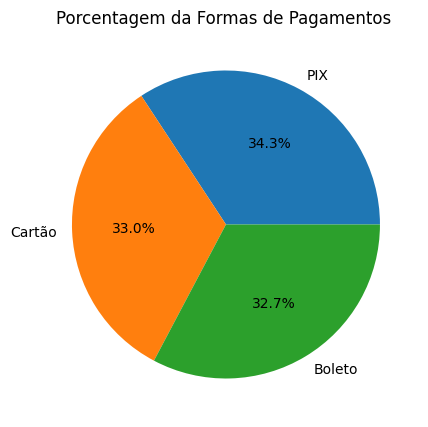

In [66]:
#2.

plt.figure(figsize=(5,5))
plt.pie(pagamentos.values, labels=pagamentos.index, autopct='%1.1f%%')
plt.title('Porcentagem da Formas de Pagamentos ')
plt.show()

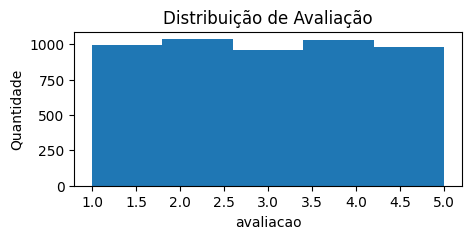

In [65]:
#3.

plt.figure(figsize=(5,2))
plt.hist(df['avaliacao'], bins=5)
plt.xlabel('avaliacao')
plt.ylabel('Quantidade')
plt.title('Distribuição de Avaliação')
plt.show()
